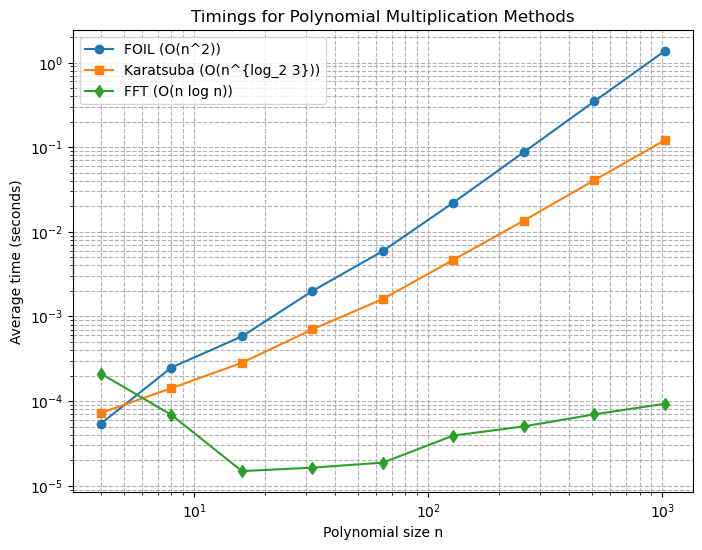

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

def foil(a, b):
    """
    Multiply two polynomials (represented as 1D NumPy arrays of coefficients
    in increasing order, e.g., [1, 2] represents 1 + 2x) using a recursive FOIL algorithm.
    Assumes len(a) is a power of 2.
    
    Returns the coefficient array of the product (length = 2*n - 1).
    """
    n = len(a)
    if n == 1:
        return np.array([a[0] * b[0]])
    
    half = n // 2
    # Split into lower and upper halves
    a0, a1 = a[:half], a[half:]
    b0, b1 = b[:half], b[half:]
    
    # Recursively compute the four products
    c0 = foil(a0, b0)       # a0 * b0
    c1 = foil(a0, b1)       # a0 * b1
    c2 = foil(a1, b0)       # a1 * b0
    c3 = foil(a1, b1)       # a1 * b1
    
    # Combine: p(x) = c0 + (c1 + c2)*x^(half) + c3*x^(2*half)
    result = np.zeros(2 * n - 1)
    result[: len(c0)] += c0
    result[half: half + len(c1)] += c1
    result[half: half + len(c2)] += c2
    result[2 * half: 2 * half + len(c3)] += c3
    return result

def karatsuba(a, b):
    """
    Multiply two polynomials using Karatsuba's algorithm.
    The polynomials are represented as 1D NumPy arrays (coefficients in increasing order).
    Assumes len(a) is a power of 2.
    
    Returns the coefficient array of the product (length = 2*n - 1).
    """
    n = len(a)
    if n == 1:
        return np.array([a[0] * b[0]])
    
    half = n // 2
    a0, a1 = a[:half], a[half:]
    b0, b1 = b[:half], b[half:]
    
    p0 = karatsuba(a0, b0)         # a0 * b0
    p2 = karatsuba(a1, b1)         # a1 * b1
    p1 = karatsuba(a0 + a1, b0 + b1)  # (a0 + a1)*(b0 + b1)
    
    # Middle term = p1 - p0 - p2
    middle = p1 - p0 - p2
    
    result = np.zeros(2 * n - 1)
    result[: len(p0)] += p0
    result[half: half + len(middle)] += middle
    result[2 * half: 2 * half + len(p2)] += p2
    return result

def fft_polymul(a, b):
    """
    Multiply two polynomials using FFT.
    The polynomials are represented as 1D NumPy arrays (coefficients in increasing order).
    
    Returns the coefficient array of the product (length = 2*n - 1).
    """
    n = len(a)
    N = 2 * n - 1
    # For FFT efficiency, pad length to a power of 2
    N_fft = 1
    while N_fft < N:
        N_fft *= 2

    A = np.fft.fft(a, N_fft)
    B = np.fft.fft(b, N_fft)
    C = A * B
    c = np.fft.ifft(C)
    # Remove any tiny imaginary parts due to numerical error
    c = np.real_if_close(c, tol=1e-9)
    return c[:N]

# -------------------------------
# Main timing and plotting script
# -------------------------------
# Use polynomial sizes that are powers of 2 (e.g., n = 4, 8, 16, …, 1024)
n_vals = 2 ** np.arange(2, 11)  # n = 4, 8, 16, ..., 1024
num_trials = 5  # number of trials (first trial in each case is treated as a warm-up)

foil_times = []
karatsuba_times = []
fft_times = []

for n in n_vals:
    t_foil = 0.0
    t_karatsuba = 0.0
    t_fft = 0.0
    for trial in range(num_trials + 1):
        # Generate two random polynomials of degree n-1
        a = np.random.rand(n)
        b = np.random.rand(n)
        
        # Time FOIL
        start = time.perf_counter()
        c_foil = foil(a, b)
        elapsed = time.perf_counter() - start
        if trial > 0:  # discard first trial (warm-up)
            t_foil += elapsed

        # Time Karatsuba
        start = time.perf_counter()
        c_karatsuba = karatsuba(a, b)
        elapsed = time.perf_counter() - start
        if trial > 0:
            t_karatsuba += elapsed

        # Time FFT-based multiplication
        start = time.perf_counter()
        c_fft = fft_polymul(a, b)
        elapsed = time.perf_counter() - start
        if trial > 0:
            t_fft += elapsed

        # (Optional) Verify that the results are all close.
        if not np.allclose(c_foil, c_karatsuba, atol=1e-6):
            print("Warning: FOIL and Karatsuba results differ for n =", n)
        if not np.allclose(c_foil, c_fft, atol=1e-6):
            print("Warning: FOIL and FFT results differ for n =", n)

    foil_times.append(t_foil / num_trials)
    karatsuba_times.append(t_karatsuba / num_trials)
    fft_times.append(t_fft / num_trials)

# Plot the timings on a log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(n_vals, foil_times, 'o-', label='FOIL (O(n^2))')
plt.loglog(n_vals, karatsuba_times, 's-', label='Karatsuba (O(n^{log_2 3}))')
plt.loglog(n_vals, fft_times, 'd-', label='FFT (O(n log n))')
plt.xlabel("Polynomial size n")
plt.ylabel("Average time (seconds)")
plt.title("Timings for Polynomial Multiplication Methods")
plt.legend(loc="upper left")
plt.grid(True, which="both", linestyle="--")
plt.show()
